# The revised Figure 3: benchmark and convergence, built interactively

This notebook builds `output/convergence_rule150.pdf` and is meant to be edited. Every
drawing decision is a keyword, so the figure can be retuned here without changing the
manuscript script.

Panel A is the published Figure 3: the exact spectrum of rule 150 on $N = 101$ cells
against the sorted index $k$, with Benettin's QR algorithm and direct multiplication in
float16 and float64 at $T = 200$, and an inset over the leading exponents.

Panel B is the error of Benettin's estimate against the closed form, per exponent, for two
estimates that cost the same $T$ steps: the running average from step one, which is the
estimate drawn in panel A, and a burn-in followed by a window over the remaining steps.

The pieces live in two places. The maths is in `lyapunov.benettin`
(`benettin_log_stretch`, `windowed_spectrum`, `cumulative_spectrum`) and the drawing is in
`figures/make_convergence_figure.py` (`compute`, `build_figure`, `panel_spectrum`,
`panel_error`, `reference_table`). Nothing is reimplemented here.

In [1]:
import os
for var in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[var] = "1"          # before numpy is imported: single-thread QR, identical numbers

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

REPO = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
for folder in ("figures", "src"):
    sys.path.insert(0, str(REPO / folder))   # src too, so any kernel works, installed or not

%load_ext autoreload
%autoreload 2

import lyapunov
import _style
import make_convergence_figure as mcf
from lyapunov.benettin import windowed_spectrum, cumulative_spectrum

print("kernel:  ", sys.executable)
print("lyapunov:", Path(lyapunov.__file__).parent, f"(version {lyapunov.__version__})")
print("style knobs:", ", ".join(sorted(mcf.STYLE)))

kernel:   C:\Users\mrollier\AppData\Local\Programs\Python\Python311\python.exe
lyapunov: C:\Users\mrollier\OneDrive - UGent\Research\Cellular Automata\CA Programming\exact-lyapunov-spectra\src\lyapunov (version 1.3.0)
style knobs: connector_colour, connector_width, error_ylim, error_yticks, figsize, font_family, font_serif, font_size, height_ratios, hspace, inset_rect, inset_tick_size, inset_title_size, inset_xticks, inset_ylim, inset_yticks, label_size, legend_bbox, legend_size, line_width, marker_size, panel_label_size, panel_label_xy, tick_size, xticks, ylabel_size


## 1. The data

One QR run of 4000 steps stores $\ln|R_{ii}|$ at every step, and every estimator below is a
mean over a slice of those rows. This is the only slow part, about two seconds, so it is
done once and reused by every figure in the notebook.

`compute` also returns the four spectra of panel A and the two error curves of panel B for
the default budget: $T = 200$ steps either way, with a burn-in of 100.

In [2]:
RULE, N, T, BURN, ZOOM_K = 150, 101, 200, 100, 35

data = mcf.compute(RULE, N, T, BURN)
exact, L = data["exact"], data["L"]
print(f"stored log stretches: {L.shape[0]} steps x {L.shape[1]} directions")
print(f"exact MLE {exact[0]:.12f} (ln 3 = {np.log(3):.12f}), bottom exponent {exact[-1]:.6f}")
for label, err in (("no burn-in, 200 steps", data["err_run"]),
                   ("burn-in 100, next 100 steps", data["err_win"])):
    print(f"{label:30s}: within 1e-3 {np.mean(err < 1e-3):.2f}, within 1e-2 {np.mean(err < 1e-2):.2f}, "
          f"max {err.max():.1e}")

stored log stretches: 4000 steps x 101 directions
exact MLE 1.098612288668 (ln 3 = 1.098612288668), bottom exponent -3.332626
no burn-in, 200 steps         : within 1e-3 0.00, within 1e-2 0.04, max 1.0e-01
burn-in 100, next 100 steps   : within 1e-3 0.55, within 1e-2 0.85, max 9.0e-02


## 2. The figure as it goes to the manuscript

`build_figure` returns the figure, a dictionary of axes (`"A"`, `"B"`, `"inset"`) and the
data it used. Passing `data=` reuses the run above instead of repeating it.

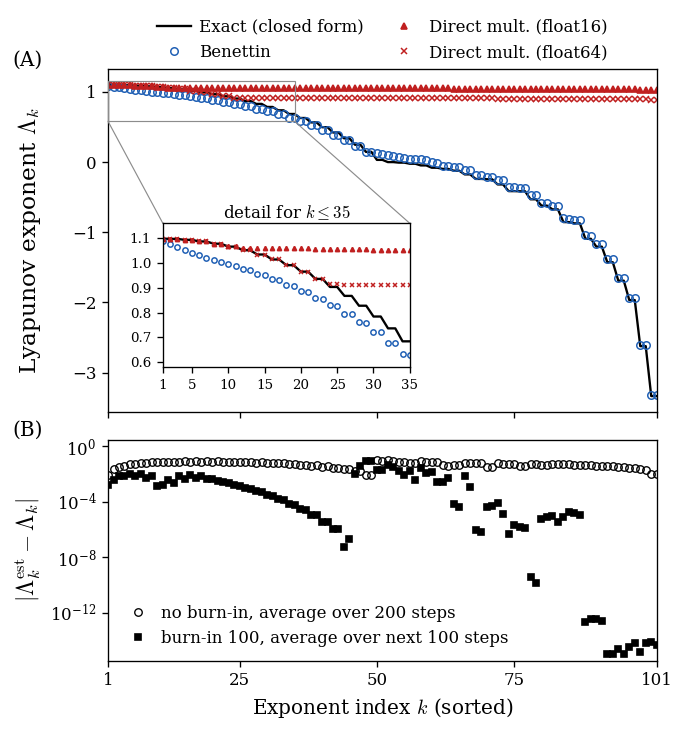

In [3]:
fig, ax, _ = mcf.build_figure(RULE, N, T, BURN, ZOOM_K, data=data)
display(fig); plt.close(fig)

## 3. Changing the estimator

The budget and the split between burn-in and window are arguments, and passing `data=`
reuses the stored run, so only the two error curves are redone. Below the same 200 steps are
split 50/150 and 150/50. Spending more of the budget on the burn-in and less on the window
raises the fraction of the spectrum within $10^{-3}$, from 0.28 to 0.69.

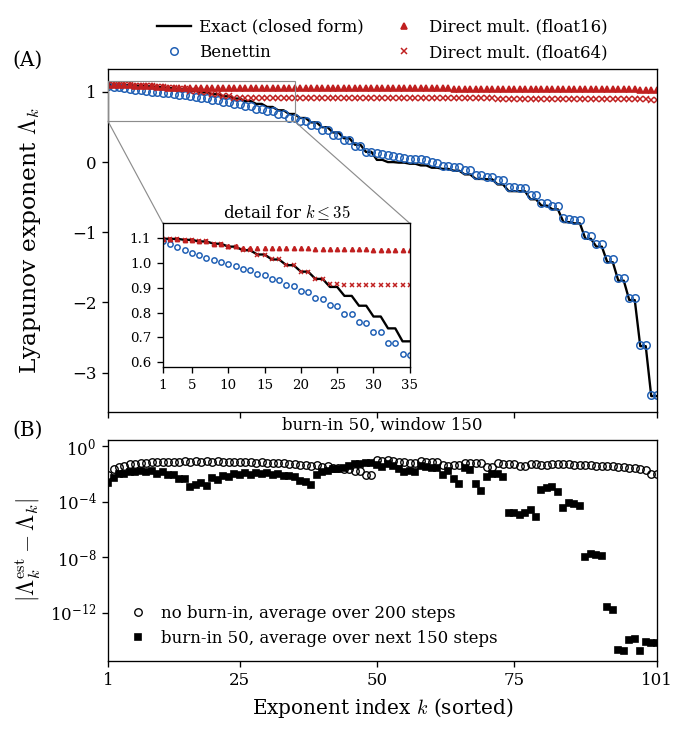

burn-in  50, window 150: within 1e-3 0.28, within 1e-2 0.62, max error 6.4e-02


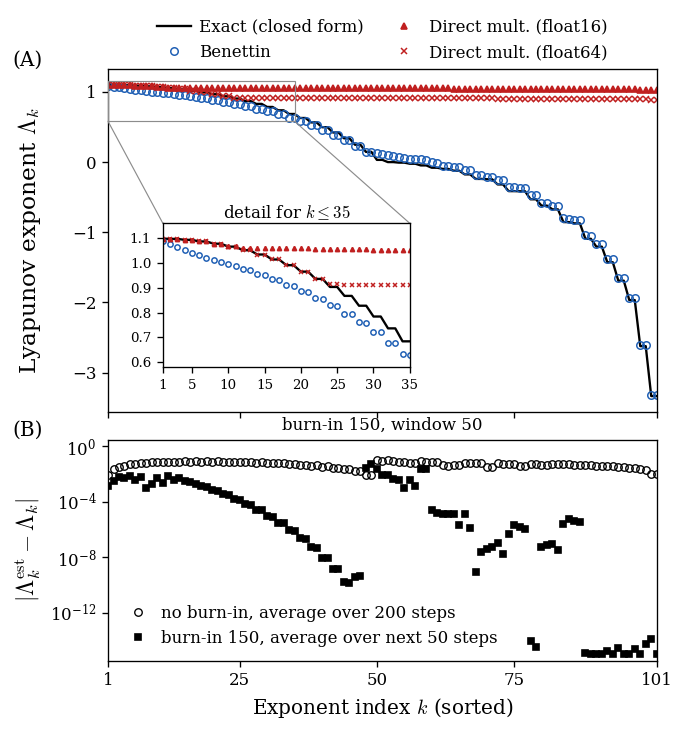

burn-in 150, window  50: within 1e-3 0.69, within 1e-2 0.95, max error 5.8e-02


In [4]:
for burn in (50, 150):
    fig, ax, d = mcf.build_figure(RULE, N, T, burn, ZOOM_K, data=data)
    ax["B"].set_title(f"burn-in {burn}, window {T - burn}", fontsize=10)
    display(fig); plt.close(fig)
    print(f"burn-in {burn:3d}, window {T - burn:3d}: within 1e-3 {np.mean(d['err_win'] < 1e-3):.2f}, "
          f"within 1e-2 {np.mean(d['err_win'] < 1e-2):.2f}, max error {d['err_win'].max():.1e}")

## 4. Changing the drawing

`mcf.STYLE` holds every layout number: figure size, panel heights, the five font sizes and
the serif family, the inset rectangle in axes coordinates and its limits, tick positions on
every axis, marker sizes, the legend anchor. Pass a dictionary of overrides as `style=`;
keys left out keep their default. The call below makes a wider figure in Times New Roman,
with a smaller inset in the upper right, larger markers and every second decade labelled on
the error axis.

The text is Computer Modern by default and the maths always is. For real LaTeX typesetting
rather than a matching font, pass `use_tex=True` instead; LaTeX is installed on this
machine, but it is slower and it is not the default anywhere in the repo.

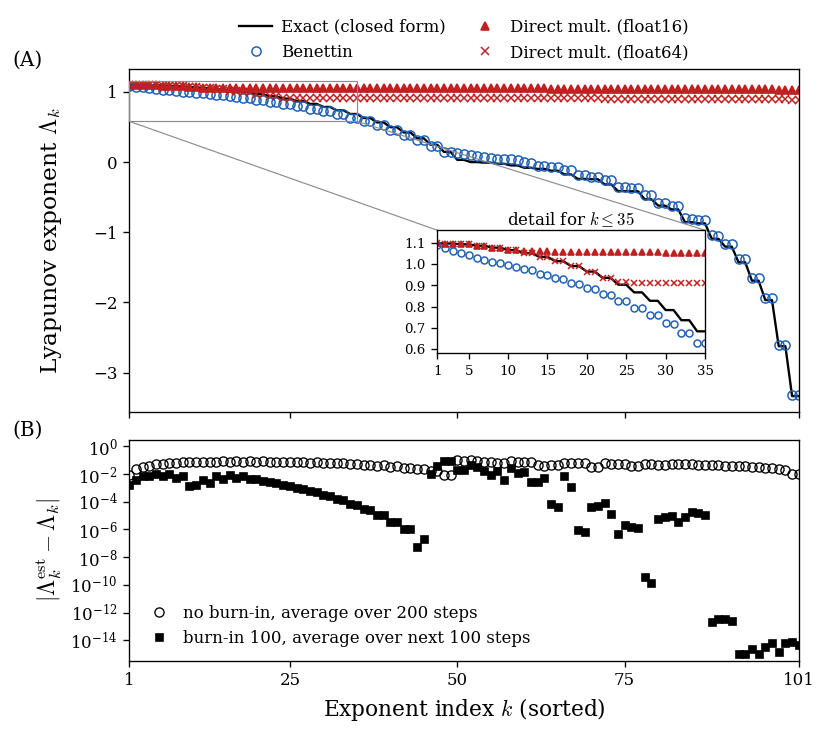

In [5]:
fig, ax, _ = mcf.build_figure(
    RULE, N, T, BURN, ZOOM_K, data=data,
    style={"figsize": (7.2, 6.4), "inset_rect": (0.46, 0.17, 0.40, 0.36),
           "marker_size": 5.5, "font_size": 12, "label_size": 13,
           "font_serif": ("Times New Roman", "DejaVu Serif"),
           "error_yticks": (1e0, 1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12, 1e-14)})
display(fig); plt.close(fig)

## 5. Adjusting the axes afterwards

The returned axes are ordinary Matplotlib axes, so anything else is done on them directly:
limits, ticks, annotations, extra series. Here panel B is restricted to the range that
matters for a reader, and the two slow bands are marked.

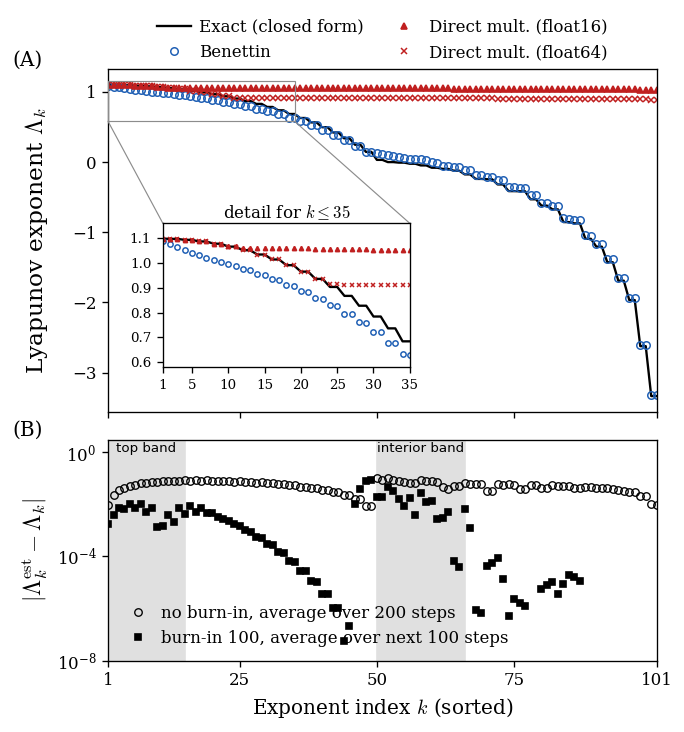

In [6]:
fig, ax, _ = mcf.build_figure(RULE, N, T, BURN, ZOOM_K, data=data)
ax["B"].set_ylim(1e-8, 3)
for lo, hi in ((1, 15), (50, 66)):
    ax["B"].axvspan(lo, hi, color="0.88", zorder=0)
ax["B"].text(8, 1.0, "top band", ha="center", fontsize=8)
ax["B"].text(58, 1.0, "interior band", ha="center", fontsize=8)
display(fig); plt.close(fig)

## 6. Building panel B from scratch

For estimators the figure does not offer, take slices of `L` directly. `windowed_spectrum(L,
burn, window)` is the mean over steps `burn + 1` to `burn + window`, sorted descending;
`cumulative_spectrum(L, T)` is the running average from step one. Sorting before the
comparison is essential, because nearly degenerate pairs exchange places while converging.

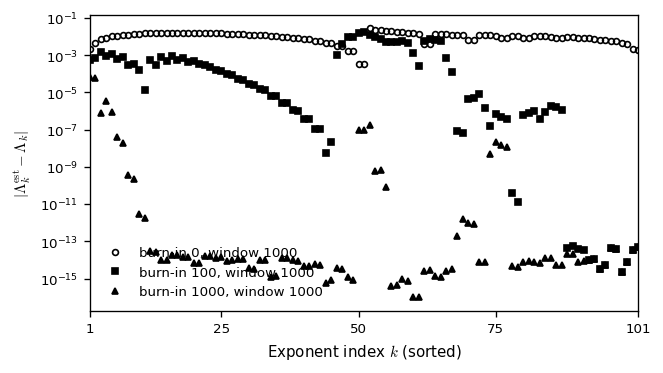

In [7]:
fig, axb = plt.subplots(figsize=(5.9, 3.2))
for burn, window, marker in ((0, 1000, "o"), (100, 1000, "s"), (1000, 1000, "^")):
    err = np.abs(windowed_spectrum(L, burn, window) - exact)
    axb.plot(np.arange(1, N + 1), np.maximum(err, 1e-16), marker, ms=3.5, lw=0,
             mfc="none" if marker == "o" else "black", mec="black",
             label=f"burn-in {burn}, window {window}")
axb.set_yscale("log"); axb.set_xlim(1, N); axb.set_xticks([1, 25, 50, 75, 101])
axb.set_xlabel(r"Exponent index $k$ (sorted)")
axb.set_ylabel(r"$|\Lambda_k^{\rm est} - \Lambda_k|$")
axb.legend(frameon=False, fontsize=8, loc="lower left")
display(fig); plt.close(fig)

## 7. Saving

`_style.save` is the repo convention: a PDF into `output/` named after the stem. The
manuscript figure is written below. To keep a variant, save it under a different stem so it
does not overwrite the manuscript file.

In [8]:
fig, ax, _ = mcf.build_figure(RULE, N, T, BURN, ZOOM_K, data=data)
path = _style.save(fig, f"convergence_rule{RULE}")
print("saved", path.relative_to(REPO).as_posix())

# A variant, kept out of the way of the manuscript figure:
# fig2, ax2, _ = mcf.build_figure(RULE, N, T, 300, ZOOM_K, data=data)
# _style.save(fig2, f"convergence_rule{RULE}_burn300")

saved output/convergence_rule150.pdf


## 8. The numbers behind the figure

`reference_table` prints the fraction of the spectrum within $10^{-3}$ and $10^{-2}$ of the
closed form, and the largest error, for a window of 1000 steps after each burn-in on the
grid, together with the running average at $T = 4000$. It returns the rows that disagree
with the reference values, and the cell asserts that there are none.

It also reports, per exponent, the smallest burn-in on the grid whose pairwise envelope
$\max(e_k, e_{k+1})$ is below $10^{-2}$ and $10^{-3}$. The windowed error is not monotone in
the burn-in at every $k$, since nearly degenerate pairs in the interior band swap, so two
definitions are printed: the first burn-in on the grid that passes, and the first from which
every larger one also passes. They differ at two exponents at $10^{-2}$ and nowhere at
$10^{-3}$.

In [9]:
failures = mcf.reference_table(L, exact)
assert not failures, "reference table mismatch:\n  " + "\n  ".join(failures)
print("\nreference table: every row matches")

reference table, N = 101, Q0 = I, W = 1000
  estimator                    steps   <1e-3   <1e-2   max err
  running average, T = 4000     4000    0.09    1.00   6.9e-03  [ok]
  windowed, B = 0               1000    0.02    0.45   2.8e-02  [ok]
  windowed, B = 100             1100    0.79    0.97   1.8e-02  [ok]
  windowed, B = 300             1300    0.89    0.98   1.8e-02  [ok]
  windowed, B = 1000            2000    1.00    1.00   6.5e-05  [ok]
  windowed, B = 3000            4000    1.00    1.00   4.0e-07  [ok]
  envelope < 0.01, first B that passes                   : B = 0: 33, B = 30: 61, B = 100: 4, B = 300: 1, B = 1000: 2
  envelope < 0.01, first B from which all larger B pass  : B = 0: 31, B = 30: 61, B = 100: 4, B = 300: 1, B = 1000: 4
    the two definitions differ at k = [49, 50]
  envelope < 0.001, first B that passes                   : B = 30: 41, B = 100: 33, B = 300: 12, B = 1000: 15
  envelope < 0.001, first B from which all larger B pass  : B = 30: 41, B = 100: 33, B